# Retail Sales Performance Dashboard — Week 4
## ETL Pipeline in Azure Databricks
### Setup: Upload cleaned sales data to DBFS

In [0]:
sales_data = """sale_id,store_id,product_id,quantity,price,cost,sale_date,discount_pct,revenue,total_cost,profit,profit_margin_pct
1,1,1,5,599.0,350.0,2026-06-01,5.0,2845.25,1750.0,1095.25,38.49
2,1,3,10,499.0,200.0,2026-06-01,0.0,4990.0,2000.0,2990.0,59.92
3,2,2,3,1499.0,900.0,2026-06-02,10.0,4047.3,2700.0,1347.3,33.29
4,2,4,5,2999.0,1800.0,2026-06-02,0.0,14995.0,9000.0,5995.0,39.98
5,3,5,1,3499.0,2200.0,2026-06-03,15.0,2974.15,2200.0,774.15,26.03
6,3,6,7,899.0,450.0,2026-06-03,0.0,6293.0,3150.0,3143.0,49.94
7,4,7,4,1299.0,700.0,2026-06-04,5.0,4936.2,2800.0,2136.2,43.28
8,4,8,6,799.0,400.0,2026-06-04,0.0,4794.0,2400.0,2394.0,49.94
9,5,1,8,599.0,350.0,2026-06-05,0.0,4792.0,2800.0,1992.0,41.57
10,5,3,12,499.0,200.0,2026-06-05,20.0,4790.4,2400.0,2390.4,49.9
11,1,4,2,2999.0,1800.0,2026-06-06,0.0,5998.0,3600.0,2398.0,39.98
12,2,7,3,1299.0,700.0,2026-06-07,5.0,3702.15,2100.0,1602.15,43.28
13,3,2,3,1499.0,900.0,2026-06-07,0.0,4497.0,2700.0,1797.0,39.96
14,4,6,9,899.0,450.0,2026-06-07,5.0,7685.45,4050.0,3635.45,47.3
15,5,7,5,1299.0,700.0,2026-06-08,0.0,6495.0,3500.0,2995.0,46.11
16,1,8,3,799.0,400.0,2026-06-08,0.0,2397.0,1200.0,1197.0,49.94
17,2,1,6,599.0,350.0,2026-06-09,10.0,3234.6,2100.0,1134.6,35.08
18,3,3,5,499.0,200.0,2026-06-09,0.0,2495.0,1000.0,1495.0,59.92
19,4,4,2,2999.0,1800.0,2026-06-10,0.0,5998.0,3600.0,2398.0,39.98
20,5,5,4,3499.0,2200.0,2026-06-10,25.0,10497.0,8800.0,1697.0,16.17
22,2,7,3,1299.0,700.0,2026-06-11,5.0,3702.15,2100.0,1602.15,43.28
23,3,8,5,799.0,400.0,2026-06-11,0.0,3995.0,2000.0,1995.0,49.94
24,4,1,10,599.0,350.0,2026-06-12,0.0,5990.0,3500.0,2490.0,41.57
25,5,2,2,1499.0,900.0,2026-06-12,10.0,2698.2,1800.0,898.2,33.29"""

products_data = """product_id,product_name,category,price,cost
1,Wireless Mouse,Electronics,599.0,350.0
2,Bluetooth Speaker,Electronics,1499.0,900.0
3,Cotton T-Shirt,Apparel,499.0,200.0
4,Running Shoes,Footwear,2999.0,1800.0
5,Coffee Maker,Appliances,3499.0,2200.0
6,Yoga Mat,Fitness,899.0,450.0
7,Backpack,Accessories,1299.0,700.0
8,Desk Lamp,Home,799.0,400.0"""

stores_data = """store_id,store_name,region,city
1,Downtown Mart,South,Chennai
2,City Center Store,South,Bangalore
3,North Plaza,North,Delhi
4,West End Outlet,West,Mumbai
5,East Side Shop,East,Kolkata"""

dbutils.fs.put('/FileStore/retail_sales/sales_cleaned.csv', sales_data, overwrite=True)
dbutils.fs.put('/FileStore/retail_sales/products.csv', products_data, overwrite=True)
dbutils.fs.put('/FileStore/retail_sales/stores.csv', stores_data, overwrite=True)
print('All files uploaded to DBFS!')


Wrote 1651 bytes.
Wrote 341 bytes.
Wrote 183 bytes.
All files uploaded to DBFS!


## Part 1: Load Data into Databricks

In [0]:
df_sales = spark.read.csv('/FileStore/retail_sales/sales_cleaned.csv', header=True, inferSchema=True)
df_products = spark.read.csv('/FileStore/retail_sales/products.csv', header=True, inferSchema=True)
df_stores = spark.read.csv('/FileStore/retail_sales/stores.csv', header=True, inferSchema=True)

print('sales schema:')
df_sales.printSchema()
print('products schema:')
df_products.printSchema()
print('stores schema:')
df_stores.printSchema()

display(df_sales)


sales schema:
root
 |-- sale_id: integer (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- price: double (nullable = true)
 |-- cost: double (nullable = true)
 |-- sale_date: date (nullable = true)
 |-- discount_pct: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- total_cost: double (nullable = true)
 |-- profit: double (nullable = true)
 |-- profit_margin_pct: double (nullable = true)

products schema:
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- price: double (nullable = true)
 |-- cost: double (nullable = true)

stores schema:
root
 |-- store_id: integer (nullable = true)
 |-- store_name: string (nullable = true)
 |-- region: string (nullable = true)
 |-- city: string (nullable = true)



sale_id,store_id,product_id,quantity,price,cost,sale_date,discount_pct,revenue,total_cost,profit,profit_margin_pct
1,1,1,5,599.0,350.0,2026-06-01,5.0,2845.25,1750.0,1095.25,38.49
2,1,3,10,499.0,200.0,2026-06-01,0.0,4990.0,2000.0,2990.0,59.92
3,2,2,3,1499.0,900.0,2026-06-02,10.0,4047.3,2700.0,1347.3,33.29
4,2,4,5,2999.0,1800.0,2026-06-02,0.0,14995.0,9000.0,5995.0,39.98
5,3,5,1,3499.0,2200.0,2026-06-03,15.0,2974.15,2200.0,774.15,26.03
6,3,6,7,899.0,450.0,2026-06-03,0.0,6293.0,3150.0,3143.0,49.94
7,4,7,4,1299.0,700.0,2026-06-04,5.0,4936.2,2800.0,2136.2,43.28
8,4,8,6,799.0,400.0,2026-06-04,0.0,4794.0,2400.0,2394.0,49.94
9,5,1,8,599.0,350.0,2026-06-05,0.0,4792.0,2800.0,1992.0,41.57
10,5,3,12,499.0,200.0,2026-06-05,20.0,4790.4,2400.0,2390.4,49.9


## Part 2: Save as Bronze Delta Tables

In [0]:
spark.sql('DROP TABLE IF EXISTS bronze_sales')
spark.sql('DROP TABLE IF EXISTS bronze_products')
spark.sql('DROP TABLE IF EXISTS bronze_stores')

df_sales.write.format('delta').mode('overwrite').saveAsTable('bronze_sales')
df_products.write.format('delta').mode('overwrite').saveAsTable('bronze_products')
df_stores.write.format('delta').mode('overwrite').saveAsTable('bronze_stores')
print('Bronze tables created!')


Bronze tables created!


## Part 3: Clean and Transform — Silver Layer

In [0]:
from pyspark.sql.functions import col, when, round as spark_round, date_format, avg, sum as spark_sum

# Handle nulls
df_sales = df_sales.fillna({'discount_pct': 0, 'revenue': 0, 'profit': 0})
print('Nulls handled')


Nulls handled


In [0]:
# Join sales with products and stores
df_silver = df_sales \
    .join(df_products.select('product_id', 'product_name', 'category'), 'product_id', 'inner') \
    .join(df_stores, 'store_id', 'inner')

display(df_silver)


store_id,product_id,sale_id,quantity,price,cost,sale_date,discount_pct,revenue,total_cost,profit,profit_margin_pct,product_name,category,store_name,region,city
1,1,1,5,599.0,350.0,2026-06-01,5.0,2845.25,1750.0,1095.25,38.49,Wireless Mouse,Electronics,Downtown Mart,South,Chennai
1,3,2,10,499.0,200.0,2026-06-01,0.0,4990.0,2000.0,2990.0,59.92,Cotton T-Shirt,Apparel,Downtown Mart,South,Chennai
2,2,3,3,1499.0,900.0,2026-06-02,10.0,4047.3,2700.0,1347.3,33.29,Bluetooth Speaker,Electronics,City Center Store,South,Bangalore
2,4,4,5,2999.0,1800.0,2026-06-02,0.0,14995.0,9000.0,5995.0,39.98,Running Shoes,Footwear,City Center Store,South,Bangalore
3,5,5,1,3499.0,2200.0,2026-06-03,15.0,2974.15,2200.0,774.15,26.03,Coffee Maker,Appliances,North Plaza,North,Delhi
3,6,6,7,899.0,450.0,2026-06-03,0.0,6293.0,3150.0,3143.0,49.94,Yoga Mat,Fitness,North Plaza,North,Delhi
4,7,7,4,1299.0,700.0,2026-06-04,5.0,4936.2,2800.0,2136.2,43.28,Backpack,Accessories,West End Outlet,West,Mumbai
4,8,8,6,799.0,400.0,2026-06-04,0.0,4794.0,2400.0,2394.0,49.94,Desk Lamp,Home,West End Outlet,West,Mumbai
5,1,9,8,599.0,350.0,2026-06-05,0.0,4792.0,2800.0,1992.0,41.57,Wireless Mouse,Electronics,East Side Shop,East,Kolkata
5,3,10,12,499.0,200.0,2026-06-05,20.0,4790.4,2400.0,2390.4,49.9,Cotton T-Shirt,Apparel,East Side Shop,East,Kolkata


In [0]:
# Create sale_month
df_silver = df_silver.withColumn('sale_month', date_format(col('sale_date'), 'yyyy-MM'))

# Create profit_band
df_silver = df_silver.withColumn('profit_band',
    when(col('profit_margin_pct') >= 50, 'High')
    .when(col('profit_margin_pct') >= 35, 'Medium')
    .otherwise('Low')
)

display(df_silver.select('sale_id', 'sale_date', 'sale_month', 'profit_margin_pct', 'profit_band'))


sale_id,sale_date,sale_month,profit_margin_pct,profit_band
1,2026-06-01,2026-06,38.49,Medium
2,2026-06-01,2026-06,59.92,High
3,2026-06-02,2026-06,33.29,Low
4,2026-06-02,2026-06,39.98,Medium
5,2026-06-03,2026-06,26.03,Low
6,2026-06-03,2026-06,49.94,Medium
7,2026-06-04,2026-06,43.28,Medium
8,2026-06-04,2026-06,49.94,Medium
9,2026-06-05,2026-06,41.57,Medium
10,2026-06-05,2026-06,49.9,Medium


In [0]:
# Save Silver Delta table
spark.sql('DROP TABLE IF EXISTS silver_sales')
df_silver.write.format('delta').mode('overwrite').saveAsTable('silver_sales')
print('Silver table saved!')


Silver table saved!


## Part 4: Gold Reports — Business Metrics

In [0]:
df_silver.createOrReplaceTempView('silver_view')

# Profit margin by category
print('--- Profit Margin by Category ---')
spark.sql("""
    SELECT category,
           ROUND(AVG(profit_margin_pct), 2) AS avg_profit_margin,
           SUM(revenue) AS total_revenue,
           SUM(profit) AS total_profit
    FROM silver_view
    GROUP BY category
    ORDER BY avg_profit_margin DESC
""").show()


--- Profit Margin by Category ---
+-----------+-----------------+-------------+------------+
|   category|avg_profit_margin|total_revenue|total_profit|
+-----------+-----------------+-------------+------------+
|    Apparel|            56.58|      12275.4|      6875.4|
|       Home|            49.94|      11186.0|      5586.0|
|    Fitness|            48.62|     13978.45|     6778.45|
|Accessories|            43.99|      18835.5|      8335.5|
|   Footwear|            39.98|      26991.0|     10791.0|
|Electronics|            37.61|     28104.35|    10754.35|
| Appliances|             21.1|     13471.15|     2471.15|
+-----------+-----------------+-------------+------------+



In [0]:
# Revenue and profit by store
print('--- Revenue & Profit by Store ---')
spark.sql("""
    SELECT store_name, region, city,
           SUM(revenue) AS total_revenue,
           SUM(profit) AS total_profit,
           ROUND(AVG(profit_margin_pct), 2) AS avg_margin
    FROM silver_view
    GROUP BY store_name, region, city
    ORDER BY total_revenue DESC
""").show()


--- Revenue & Profit by Store ---
+-----------------+------+---------+------------------+------------+----------+
|       store_name|region|     city|     total_revenue|total_profit|avg_margin|
+-----------------+------+---------+------------------+------------+----------+
|City Center Store| South|Bangalore|           29681.2|     11681.2|     38.98|
|  West End Outlet|  West|   Mumbai|          29403.65|    13053.65|     44.41|
|   East Side Shop|  East|  Kolkata|29272.600000000002|      9972.6|     37.41|
|      North Plaza| North|    Delhi|          20254.15|     9204.15|     45.16|
|    Downtown Mart| South|  Chennai|          16230.25|     7680.25|     47.08|
+-----------------+------+---------+------------------+------------+----------+



In [0]:
# Top 3 best-selling products
print('--- Top 3 Best-Selling Products ---')
spark.sql("""
    SELECT product_name, category,
           SUM(quantity) AS total_units,
           SUM(revenue) AS total_revenue
    FROM silver_view
    GROUP BY product_name, category
    ORDER BY total_revenue DESC
    LIMIT 3
""").show()


--- Top 3 Best-Selling Products ---
+--------------+-----------+-----------+-------------+
|  product_name|   category|total_units|total_revenue|
+--------------+-----------+-----------+-------------+
| Running Shoes|   Footwear|          9|      26991.0|
|      Backpack|Accessories|         15|      18835.5|
|Wireless Mouse|Electronics|         29|     16861.85|
+--------------+-----------+-----------+-------------+



In [0]:
# Underperforming products (profit margin < 35%)
print('--- Underperforming Products (Margin < 35%) ---')
spark.sql("""
    SELECT product_name, category,
           ROUND(AVG(profit_margin_pct), 2) AS avg_margin,
           SUM(revenue) AS total_revenue
    FROM silver_view
    GROUP BY product_name, category
    HAVING AVG(profit_margin_pct) < 35
    ORDER BY avg_margin ASC
""").show()


--- Underperforming Products (Margin < 35%) ---
+------------+----------+----------+-------------+
|product_name|  category|avg_margin|total_revenue|
+------------+----------+----------+-------------+
|Coffee Maker|Appliances|      21.1|     13471.15|
+------------+----------+----------+-------------+



## Part 5: Save Gold Reports as Delta / CSV

In [0]:
# Gold: profit margin by category
gold_category = spark.sql("""
    SELECT category,
           ROUND(AVG(profit_margin_pct), 2) AS avg_profit_margin,
           SUM(revenue) AS total_revenue,
           SUM(profit) AS total_profit
    FROM silver_view
    GROUP BY category
    ORDER BY avg_profit_margin DESC
""")

# Gold: store summary
gold_store = spark.sql("""
    SELECT store_name, region, city,
           SUM(revenue) AS total_revenue,
           SUM(profit) AS total_profit,
           ROUND(AVG(profit_margin_pct), 2) AS avg_margin
    FROM silver_view
    GROUP BY store_name, region, city
    ORDER BY total_revenue DESC
""")

spark.sql('DROP TABLE IF EXISTS gold_category_report')
spark.sql('DROP TABLE IF EXISTS gold_store_report')

gold_category.write.format('delta').mode('overwrite').saveAsTable('gold_category_report')
gold_store.write.format('delta').mode('overwrite').saveAsTable('gold_store_report')

gold_category.toPandas().to_csv('/tmp/gold_category_report.csv', index=False)
gold_store.toPandas().to_csv('/tmp/gold_store_report.csv', index=False)

print('Gold Delta tables and CSV files saved!')


Gold Delta tables and CSV files saved!


## Part 6: Visualizations

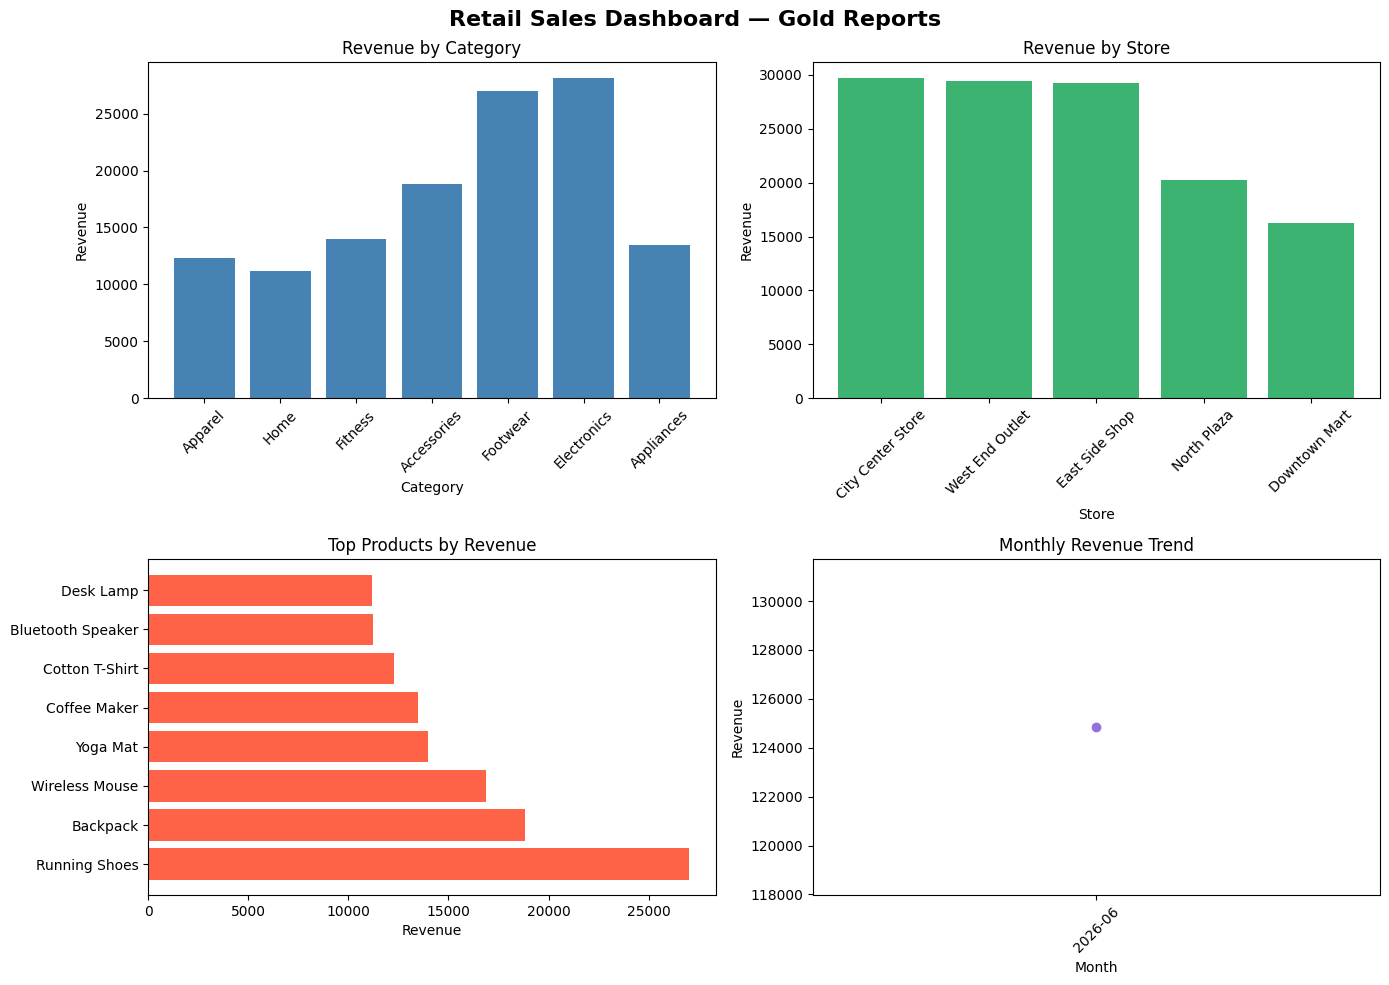

In [0]:
import matplotlib.pyplot as plt

cat_pd = gold_category.toPandas()
store_pd = gold_store.toPandas()
product_pd = spark.sql("""
    SELECT product_name, SUM(revenue) AS total_revenue
    FROM silver_view GROUP BY product_name ORDER BY total_revenue DESC
""").toPandas()
trend_pd = spark.sql("""
    SELECT sale_month, SUM(revenue) AS monthly_revenue
    FROM silver_view GROUP BY sale_month ORDER BY sale_month
""").toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(cat_pd['category'], cat_pd['total_revenue'], color='steelblue')
axes[0,0].set_title('Revenue by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Revenue')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].bar(store_pd['store_name'], store_pd['total_revenue'], color='mediumseagreen')
axes[0,1].set_title('Revenue by Store')
axes[0,1].set_xlabel('Store')
axes[0,1].set_ylabel('Revenue')
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].barh(product_pd['product_name'], product_pd['total_revenue'], color='tomato')
axes[1,0].set_title('Top Products by Revenue')
axes[1,0].set_xlabel('Revenue')

axes[1,1].plot(trend_pd['sale_month'], trend_pd['monthly_revenue'], marker='o', color='mediumpurple')
axes[1,1].set_title('Monthly Revenue Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Revenue')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Retail Sales Dashboard — Gold Reports', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
